In [1]:
import os
import gc
import shutil
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler

from torchvision import transforms
from torchvision.models import (
    densenet121,
    densenet201,
    efficientnet_b0,
    DenseNet121_Weights,
    DenseNet201_Weights,
    EfficientNet_B0_Weights
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    recall_score,
    roc_auc_score
)

import matplotlib.pyplot as plt

In [2]:
# ====================================================
# DEBUG MODE
# ====================================================
DEBUG = False   # Set False for full training

In [3]:

# ---------------- MODEL SELECTION ----------------

model_to_be_used = "DenseNet201"
# Options:
# "DenseNet121"
# "DenseNet201"
# "EfficientNetB0"
# ---------------- BASIC SETTINGS ----------------

NUM_CLASSES = 20
FOLDS = 4
BATCH_SIZE = 64
TRAIN_FOLDS = [2, 3]  # <--- ONLY TRAIN THESE FOLDS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_PATH = "/kaggle/input/competitions/ail-7031"
IMG_DIR = os.path.join(DATA_PATH, "images/images/")

WORKING_DIR = "/kaggle/working"
MODEL_DIR = os.path.join(WORKING_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# We will save the best model here
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_model_folds_2_3.pth")

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print("✅ GPUs:", torch.cuda.device_count())
    print("✅ Device:", torch.cuda.get_device_name(0))

✅ GPUs: 2
✅ Device: Tesla T4


In [4]:

train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
test_df = pd.read_csv(f"{DATA_PATH}/test.csv")
sample_sub = pd.read_csv(f"{DATA_PATH}/sample_submission.csv")
    
label_cols = sample_sub.columns[1:]

PROGRESSIVE_SIZES = [224,320,384]
PROGRESSIVE_EPOCHS = [3,2,2]

best_score = -1e9

if DEBUG:
    print("⚠️ DEBUG MODE ENABLED")

    # First compute labels from full dataset
    labels_full = np.argmax(train_df[label_cols].values, axis=1)

    # Attach labels temporarily
    train_df["_label_tmp_"] = labels_full

    # Take safe number per class
    debug_samples_per_class = 50

    train_df = (
        train_df
        .groupby("_label_tmp_")
        .head(debug_samples_per_class)
        .reset_index(drop=True)
    )

    # Remove temp column
    train_df = train_df.drop(columns=["_label_tmp_"])

    # Reduce test too
    test_df = test_df.sample(200, random_state=42).reset_index(drop=True)

    PROGRESSIVE_SIZES = [224]
    PROGRESSIVE_EPOCHS = [1]

    print("Train size (debug):", len(train_df))

In [5]:
class_counts = train_df[label_cols].sum().values
total_samples = class_counts.sum()

# avoid division by zero
class_counts_safe = np.where(class_counts == 0, 1, class_counts)

weights = total_samples / (NUM_CLASSES * class_counts_safe)

weights = np.clip(weights, 0.5, 10)

# Reduce dominance of "No Finding"
weights[0] *= 0.5

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print("⚖️ Class Counts:", class_counts)
print("⚖️ Class Weights:", weights)

⚖️ Class Counts: [ 3135   800   868   435  2875   229   519    49  6941  1665  2036   811
   213  1485    59     7    32   339   121 45439]
⚖️ Class Weights: [ 0.54272727  4.253625    3.92039171  7.82275862  1.18361739 10.
  6.5566474  10.          0.5         2.04378378  1.67136542  4.19593095
 10.          2.29151515 10.         10.         10.         10.
 10.          0.5       ]


In [6]:
class XRayDataset(Dataset):

    def __init__(self, df, img_dir, transform=None, is_test=False, label_cols=None):
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        
        # -----------------------------------------------------------
        # OPTIMIZATION 1: Pre-calculate file paths once
        # -----------------------------------------------------------
        # This removes thousands of slow "os.path.exists" calls from the training loop
        self.file_paths = []
        self.ids = df["id"].values
        
        print(f"Indexing {len(df)} file paths... (This happens once)")
        
        # We build a list of valid paths. If a file is missing, we store None.
        for img_id in self.ids:
            base_path = os.path.join(img_dir, img_id)
            
            # Check extensions priority
            if os.path.exists(base_path):
                self.file_paths.append(base_path)
            elif os.path.exists(base_path + ".png"):
                self.file_paths.append(base_path + ".png")
            elif os.path.exists(base_path + ".jpg"):
                self.file_paths.append(base_path + ".jpg")
            else:
                self.file_paths.append(None) # File not found

        # -----------------------------------------------------------
        # OPTIMIZATION 2: Pre-process labels to NumPy
        # -----------------------------------------------------------
        if not is_test:
            # If label_cols not passed, try to use the global variable or infer
            if label_cols is None:
                # Assuming 'sample_sub' or specific columns exist as per your original code
                # You can pass this list explicitly when creating the dataset
                try:
                    label_cols = sample_sub.columns[1:]
                except:
                    # Fallback if sample_sub isn't defined in this scope
                    label_cols = df.columns[1:] 
            
            # Convert to float32 and pre-calculate argmax
            # This avoids doing pandas lookups inside __getitem__
            self.labels = np.argmax(df[label_cols].values, axis=1).astype(np.int64)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        
        # Fast List Access (O(1)) instead of slow Pandas iloc
        img_path = self.file_paths[idx]
        
        # Handle Missing Images (Fallback to black image)
        if img_path is None:
            image = Image.new("RGB", (256, 256))
        else:
            try:
                # We already know the path exists, so just open it
                image = Image.open(img_path).convert("RGB")
            except:
                image = Image.new("RGB", (256, 256))

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, self.ids[idx]

        # Fast Array Access
        label = self.labels[idx]

        return image, torch.tensor(label, dtype=torch.long)

In [7]:

def get_transforms(img_size, mode="train"):

    if mode == "train":

        return transforms.Compose([

            transforms.Resize((img_size,img_size)),

            transforms.RandomHorizontalFlip(),

            transforms.RandomRotation(10),

            transforms.RandomAffine(
                degrees=0,
                translate=(0.05,0.05)
            ),

            transforms.ColorJitter(
                brightness=0.1,
                contrast=0.1
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                [0.485,0.456,0.406],
                [0.229,0.224,0.225]
            )
        ])

    else:

        return transforms.Compose([

            transforms.Resize((img_size,img_size)),

            transforms.ToTensor(),

            transforms.Normalize(
                [0.485,0.456,0.406],
                [0.229,0.224,0.225]
            )
        ])

In [8]:

def asymmetric_score(y_true, y_pred):

    scores = []

    for c in range(NUM_CLASSES):

        tp = np.sum((y_true==c) & (y_pred==c))
        fp = np.sum((y_true!=c) & (y_pred==c))
        fn = np.sum((y_true==c) & (y_pred!=c))

        nc = np.sum(y_true==c)

        if nc == 0:
            continue

        score = (tp - fp - 5*fn) / nc

        scores.append(score)

    return np.mean(scores)

In [9]:

def find_best_thresholds(probs, targets):

    thresholds = []

    for c in range(NUM_CLASSES):

        best_t = 0.5
        best_score = -1e9

        for t in np.linspace(0.05,0.9,18):

            pred = (probs[:,c] > t).astype(int)
            true = (targets==c).astype(int)

            tp = np.sum((pred==1)&(true==1))
            fp = np.sum((pred==1)&(true==0))
            fn = np.sum((pred==0)&(true==1))

            nc = np.sum(true)

            if nc == 0:
                continue

            score = (tp - fp - 5*fn)/nc

            if score > best_score:

                best_score = score
                best_t = t

        thresholds.append(best_t)

    return thresholds

In [10]:

labels = np.argmax(train_df[label_cols].values, axis=1)

kf = StratifiedKFold(
    n_splits=FOLDS,
    shuffle=True,
    random_state=42
)

In [11]:

sample_weights = []

for row in train_df[label_cols].values:

    class_idx = np.argmax(row)

    sample_weights.append(weights[class_idx])

sample_weights = np.array(sample_weights)

In [12]:


# Calculate sample weights for the sampler
sample_weights_full = []
for row in train_df[label_cols].values:
    class_idx = np.argmax(row)
    sample_weights_full.append(weights[class_idx])
sample_weights_full = np.array(sample_weights_full)

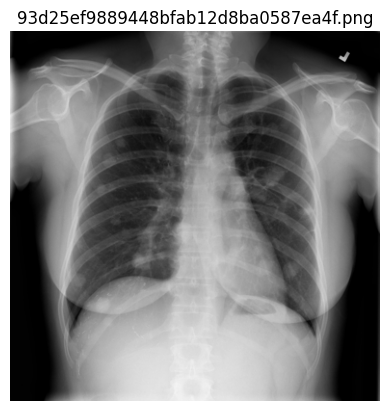

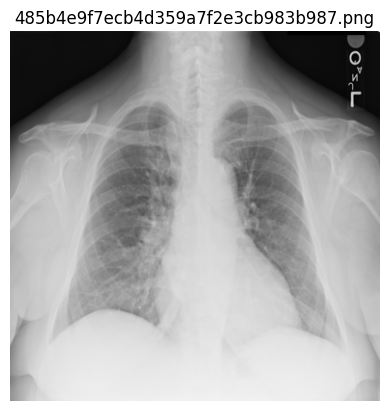

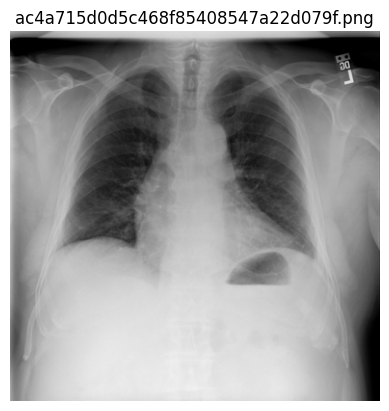

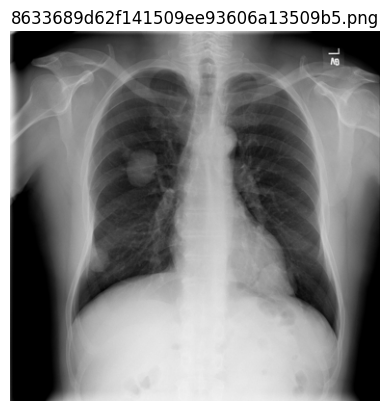

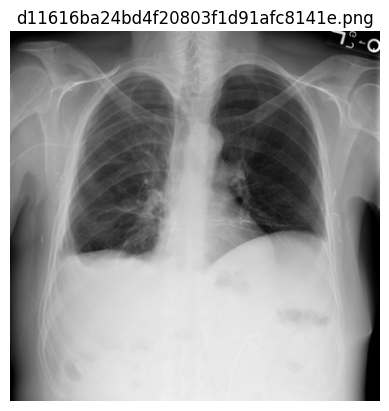

In [13]:
import matplotlib.pyplot as plt
import random

sample = train_df.sample(5)

for i,row in sample.iterrows():

    img_id = row["id"]

    img_path = os.path.join(IMG_DIR,img_id)

    if not os.path.exists(img_path):
        if os.path.exists(img_path + ".png"):
            img_path += ".png"
        elif os.path.exists(img_path + ".jpg"):
            img_path += ".jpg"

    img = Image.open(img_path)

    plt.imshow(img,cmap="gray")
    plt.title(img_id)
    plt.axis("off")
    plt.show()

In [14]:
from torch import amp
import gc

# ---------------- SETTINGS ----------------
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.fp32_precision = "tf32"
torch.backends.cudnn.conv.fp32_precision = "tf32"

target_cols = sample_sub.columns[1:]

# =============================
# GLOBAL STORAGE
# =============================

epoch_counter = 0

all_val_probs = []
all_val_targets = []

train_acc_history = []
val_acc_history = []
asym_history = []
recall_history = []
roc_history = []

print(f"🚀 Training Only Folds: {TRAIN_FOLDS}")

# ====================================================
# FOLD LOOP
# ====================================================

for fold, (train_idx, val_idx) in enumerate(kf.split(train_df, labels)):

    if fold not in TRAIN_FOLDS:
        print(f"Skipping Fold {fold}")
        continue

    print(f"\n================ FOLD {fold} ================")

    # [FIX] Define a unique path for this fold's model
    FOLD_MODEL_PATH = os.path.join(MODEL_DIR, f"{model_to_be_used}_fold_{fold}.pth")
    
    train_split = train_df.iloc[train_idx]
    val_split   = train_df.iloc[val_idx]

    # fold history
    fold_train_acc = []
    fold_val_acc = []
    fold_asym = []
    fold_recall = []
    fold_roc = []

    fold_best_score = -1e9
    fold_best_probs = None
    fold_best_targets = None

    # ------------------------------------------------
    # MODEL SELECTION
    # ------------------------------------------------
    if model_to_be_used == "DenseNet121":

        model = densenet121(weights=DenseNet121_Weights.DEFAULT)
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, NUM_CLASSES)
        )

    elif model_to_be_used == "DenseNet201":

        model = densenet201(weights=DenseNet201_Weights.DEFAULT)
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, NUM_CLASSES)
        )

    elif model_to_be_used == "EfficientNetB0":

        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, NUM_CLASSES)
        )

    else:
        raise ValueError("Invalid model_to_be_used")

    model = model.to(DEVICE)
    model = model.to(memory_format=torch.channels_last)

    # ------------------------------------------------
    # OPTIMIZER
    # ------------------------------------------------

    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    total_epochs = sum(PROGRESSIVE_EPOCHS)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_epochs
    )

    scaler = amp.GradScaler("cuda")

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # ------------------------------------------------
    # MULTI GPU
    # ------------------------------------------------

    if torch.cuda.device_count() > 1:
        print("Using", torch.cuda.device_count(), "GPUs")
        model = nn.DataParallel(model)

    # =================================================
    # PROGRESSIVE RESIZING
    # =================================================

    for stage, img_size in enumerate(PROGRESSIVE_SIZES):

        epochs = PROGRESSIVE_EPOCHS[stage]

        print(f"\nStage {stage+1} | Image Size {img_size}")

        train_ds = XRayDataset(
            train_split,
            IMG_DIR,
            get_transforms(img_size, "train"),
            label_cols=target_cols
        )

        val_ds = XRayDataset(
            val_split,
            IMG_DIR,
            get_transforms(img_size, "valid"),
            label_cols=target_cols
        )

        # sampler weights
        fold_sample_weights = sample_weights_full[train_idx]

        sampler = WeightedRandomSampler(
            fold_sample_weights,
            num_samples=len(fold_sample_weights),
            replacement=True
        )

        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            sampler=sampler,
            num_workers=4,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=64,
            shuffle=False,
            num_workers=4,
            pin_memory=True,
            persistent_workers=True
        )

        # freeze backbone
        if stage == 0:

            backbone = model.module.features if isinstance(model, nn.DataParallel) else model.features

            for p in backbone.parameters():
                p.requires_grad = False

        # =================================================
        # EPOCH LOOP
        # =================================================

        for epoch in range(epochs):

            print(f"\nEpoch {epoch+1}/{epochs}")

            if stage == 0 and epoch == 2:

                backbone = model.module.features if isinstance(model, nn.DataParallel) else model.features

                for p in backbone.parameters():
                    p.requires_grad = True

                print("Backbone unfrozen")

            # =============================
            # TRAIN
            # =============================

            model.train()

            running_correct = 0
            running_total = 0

            loop = tqdm(train_loader, desc="Train")

            for imgs, lbls in loop:

                imgs = imgs.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
                lbls = lbls.to(DEVICE, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                with amp.autocast("cuda"):

                    outputs = model(imgs)
                    loss = criterion(outputs, lbls)

                scaler.scale(loss).backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                scaler.step(optimizer)
                scaler.update()

                preds = torch.argmax(outputs, dim=1)

                running_correct += (preds == lbls).sum().item()
                running_total += lbls.size(0)

                loop.set_postfix(loss=loss.item(), acc=running_correct/running_total)

            scheduler.step()

            # =============================
            # VALIDATION
            # =============================

            model.eval()
            
            # Use lists to store tensors on CPU, convert to numpy only at the end
            preds_list = []
            targets_list = []
            probs_list = []
            
            with torch.inference_mode():
                val_loop = tqdm(val_loader, desc="Validation", leave=False)
                
                for imgs, lbls in val_loop:
                    imgs = imgs.to(DEVICE, non_blocking=True)
                    
                    # Use autocast in validation for speed
                    with amp.autocast("cuda"):
                        out = model(imgs)
                        probs = torch.softmax(out, dim=1)
                        pred = torch.argmax(probs, dim=1)
                    
                    # Store on CPU as tensors (faster than immediate numpy conversion)
                    preds_list.append(pred.detach().cpu())
                    targets_list.append(lbls.detach())
                    probs_list.append(probs.detach().cpu())
            
            # Concatenate once
            preds = torch.cat(preds_list).numpy()
            targets = torch.cat(targets_list).numpy()
            probs_all = torch.cat(probs_list).numpy()

            # NOTE: Removed `all_val_probs.append(probs_all)` here 
            # to prevent RAM OOM. We only save best below.
            # # Store for threshold tuning
            # all_val_probs.append(probs_all)
            # all_val_targets.append(targets)
            
            # =============================
            # METRICS
            # =============================
            acc = np.mean(preds == targets)
            asym = asymmetric_score(targets, preds)
            macro_f1 = f1_score(targets, preds, average="macro")
            recall_macro = recall_score(targets, preds, average="macro")
            
            try:
                roc = roc_auc_score(
                    np.eye(NUM_CLASSES)[targets],
                    probs_all,
                    multi_class="ovr"
                )
            except:
                roc = 0.0
            
            print("\nValidation Results")
            print(f"Accuracy: {acc:.4f} | Asymmetric Score: {asym:.4f}")
            print(f"Macro F1: {macro_f1:.4f} | Recall: {recall_macro:.4f} | ROC AUC: {roc:.4f}")


            # =============================
            # STORE HISTORY
            # =============================

            train_acc_history.append(running_correct/running_total)
            val_acc_history.append(acc)
            asym_history.append(asym)
            recall_history.append(recall_macro)
            roc_history.append(roc)

            fold_train_acc.append(running_correct/running_total)
            fold_val_acc.append(acc)
            fold_asym.append(asym)
            fold_recall.append(recall_macro)
            fold_roc.append(roc)

            epoch_counter += 1

            # 1. Update Fold Best
            if asym > fold_best_score:
                fold_best_score = asym
                fold_best_probs = probs_all.copy()
                fold_best_targets = targets.copy()

                # Save specifically for this fold using FOLD_MODEL_PATH
                model_to_save = model.module if isinstance(model, nn.DataParallel) else model
                torch.save(model_to_save.state_dict(), FOLD_MODEL_PATH)
                print(f"⭐ Best FOLD Model Saved (Score: {fold_best_score:.4f}) -> {FOLD_MODEL_PATH}")

            # 2. Update Global Best (Just for tracking, not for overwriting)
            if asym > best_score:
                best_score = asym
                # Removed the torch.save here to prevent overwriting

    # =================================================
    # SAVE FOLD OUTPUTS
    # =================================================

    np.save(f"/kaggle/working/val_probs_fold_{fold}.npy", fold_best_probs)
    np.save(f"/kaggle/working/val_targets_fold_{fold}.npy", fold_best_targets)

    np.save(f"/kaggle/working/train_acc_fold_{fold}.npy", fold_train_acc)
    np.save(f"/kaggle/working/val_acc_fold_{fold}.npy", fold_val_acc)
    np.save(f"/kaggle/working/asym_fold_{fold}.npy", fold_asym)
    np.save(f"/kaggle/working/recall_fold_{fold}.npy", fold_recall)
    np.save(f"/kaggle/working/roc_fold_{fold}.npy", fold_roc)

    # # extend global history
    # train_acc_history.extend(fold_train_acc)
    # val_acc_history.extend(fold_val_acc)
    # asym_history.extend(fold_asym)
    # recall_history.extend(fold_recall)
    # roc_history.extend(fold_roc)

    all_val_probs.append(fold_best_probs)
    all_val_targets.append(fold_best_targets)

    # cleanup
    del model, optimizer, train_loader, val_loader, scaler

    torch.cuda.empty_cache()
    gc.collect()

print("\nTraining Finished")
print("Best Asymmetric Score:", best_score)

🚀 Training Only Folds: [2, 3]
Skipping Fold 0
Skipping Fold 1

================ FOLD 2 ================
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 209MB/s]


Using 2 GPUs

Stage 1 | Image Size 224
Indexing 51044 file paths... (This happens once)
Indexing 17014 file paths... (This happens once)

Epoch 1/3


Train:   0%|          | 0/798 [00:00<?, ?it/s]

Validation:   0%|          | 0/266 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/266 [00:00<?, ?it/s]


Validation Results
Accuracy: 0.6269 | Asymmetric Score: -4.5744
Macro F1: 0.1763 | Recall: 0.1801 | ROC AUC: 0.7644
⭐ Best FOLD Model Saved (Score: -4.5744) -> /kaggle/working/models/DenseNet201_fold_3.pth

Epoch 2/2


Train:   0%|          | 0/798 [00:00<?, ?it/s]

Validation:   0%|          | 0/266 [00:00<?, ?it/s]


Validation Results
Accuracy: 0.6308 | Asymmetric Score: -4.4630
Macro F1: 0.1735 | Recall: 0.1756 | ROC AUC: 0.7543
⭐ Best FOLD Model Saved (Score: -4.4630) -> /kaggle/working/models/DenseNet201_fold_3.pth

Training Finished
Best Asymmetric Score: -4.462968987529572


In [15]:
OUTPUT_DIR = "/kaggle/working/fold_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for file in os.listdir("/kaggle/working"):
    if file.endswith(".npy") or file.endswith(".pth"):
        shutil.copy(
            os.path.join("/kaggle/working", file),
            OUTPUT_DIR
        )

shutil.make_archive(
    "/kaggle/working/folds_2_3_outputs",
    'zip',
    OUTPUT_DIR
)

'/kaggle/working/folds_2_3_outputs.zip'